<a href="https://colab.research.google.com/github/dee431/-Apple-Mac-Performance-History-1998-2026-EDA/blob/main/%F0%9F%8E%92%F0%9F%92%BB%F0%9F%8E%92%F0%9F%92%BB%F0%9F%8E%92%F0%9F%92%BB%F0%9F%8E%92%F0%9F%92%BB%F0%9F%8E%92%F0%9F%92%BB%F0%9F%8E%92Apple_Mac_Performance_History_(1998_2026)_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Cell 1**

In [1]:
import warnings
warnings.filterwarnings("ignore")
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["figure.dpi"] = 120
print("Visualization libraries initialized.")

Visualization libraries initialized.


# **cell 2**

In [3]:
import glob, os, pandas as pd
csv_name = "apple_mac_performance_history-selected-columns.csv"
search_paths = [
    f"/kaggle/input/apple-mac-performance-history/{csv_name}",
    f"../data/{csv_name}",
    f"./{csv_name}"
] + glob.glob(f"/kaggle/input/**/{csv_name}", recursive=True)

data_path = next((p for p in search_paths if os.path.exists(p)), csv_name)
df = pd.read_csv(data_path)
print(f"Loaded dataset from: {data_path}")
print(f"Dimensions: {df.shape[0]} rows x {df.shape[1]} columns\n")
display(df.head())
display(df.info())

Loaded dataset from: ./apple_mac_performance_history-selected-columns.csv
Dimensions: 35 rows x 10 columns



,model_name,model_family,model_id,release_year,release_date,cpu_architecture,processor_name,cpu_cores_total,cpu_p_cores,cpu_e_cores
0,iMac G3 233 Bondi Blue,iMac,"PowerMac2,1",1998,1998-08-15,PowerPC,PowerPC 750 (G3),1,1,0
1,PowerBook G3 400 Lombard,PowerBook,"PowerBook1,1",1999,1999-05-10,PowerPC,PowerPC 750 (G3),1,1,0
2,PowerMac G4 MDD Dual 1.25GHz,PowerMac,"PowerMac3,6",2002,2002-08-13,PowerPC,Dual PowerPC 7455 (G4),2,2,0
3,iMac G4 800 Sunflower,iMac,"PowerMac4,2",2002,2002-01-07,PowerPC,PowerPC 7450 (G4),1,1,0
4,PowerMac G5 Dual 2.0GHz,PowerMac,"PowerMac7,2",2003,2003-06-23,PowerPC,Dual PowerPC 970 (G5),2,2,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   model_name        35 non-null     object
 1   model_family      35 non-null     object
 2   model_id          35 non-null     object
 3   release_year      35 non-null     int64 
 4   release_date      35 non-null     object
 5   cpu_architecture  35 non-null     object
 6   processor_name    35 non-null     object
 7   cpu_cores_total   35 non-null     int64 
 8   cpu_p_cores       35 non-null     int64 
 9   cpu_e_cores       35 non-null     int64 
dtypes: int64(4), object(6)
memory usage: 2.9+ KB


None

# **Cell 3**

In [4]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
model_name,35,35,iMac G3 233 Bondi Blue,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_family,35,9,MacBook Pro,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_id,35,35,"PowerMac2,1",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,35.0,NaN,NaN,NaN,2014.657143,8.897927,1998.0,2006.0,2017.0,2023.0,2026.0
release_date,35,30,2024-11-08,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cpu_architecture,35,3,Apple Silicon (ARM64),15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
processor_name,35,33,PowerPC 750 (G3),2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cpu_cores_total,35.0,NaN,NaN,NaN,8.8,7.271216,1.0,2.0,8.0,13.0,28.0
cpu_p_cores,35.0,NaN,NaN,NaN,6.857143,6.169864,1.0,2.0,4.0,11.0,28.0
cpu_e_cores,35.0,NaN,NaN,NaN,1.942857,2.448804,0.0,0.0,0.0,4.0,8.0


# **Cell 4**

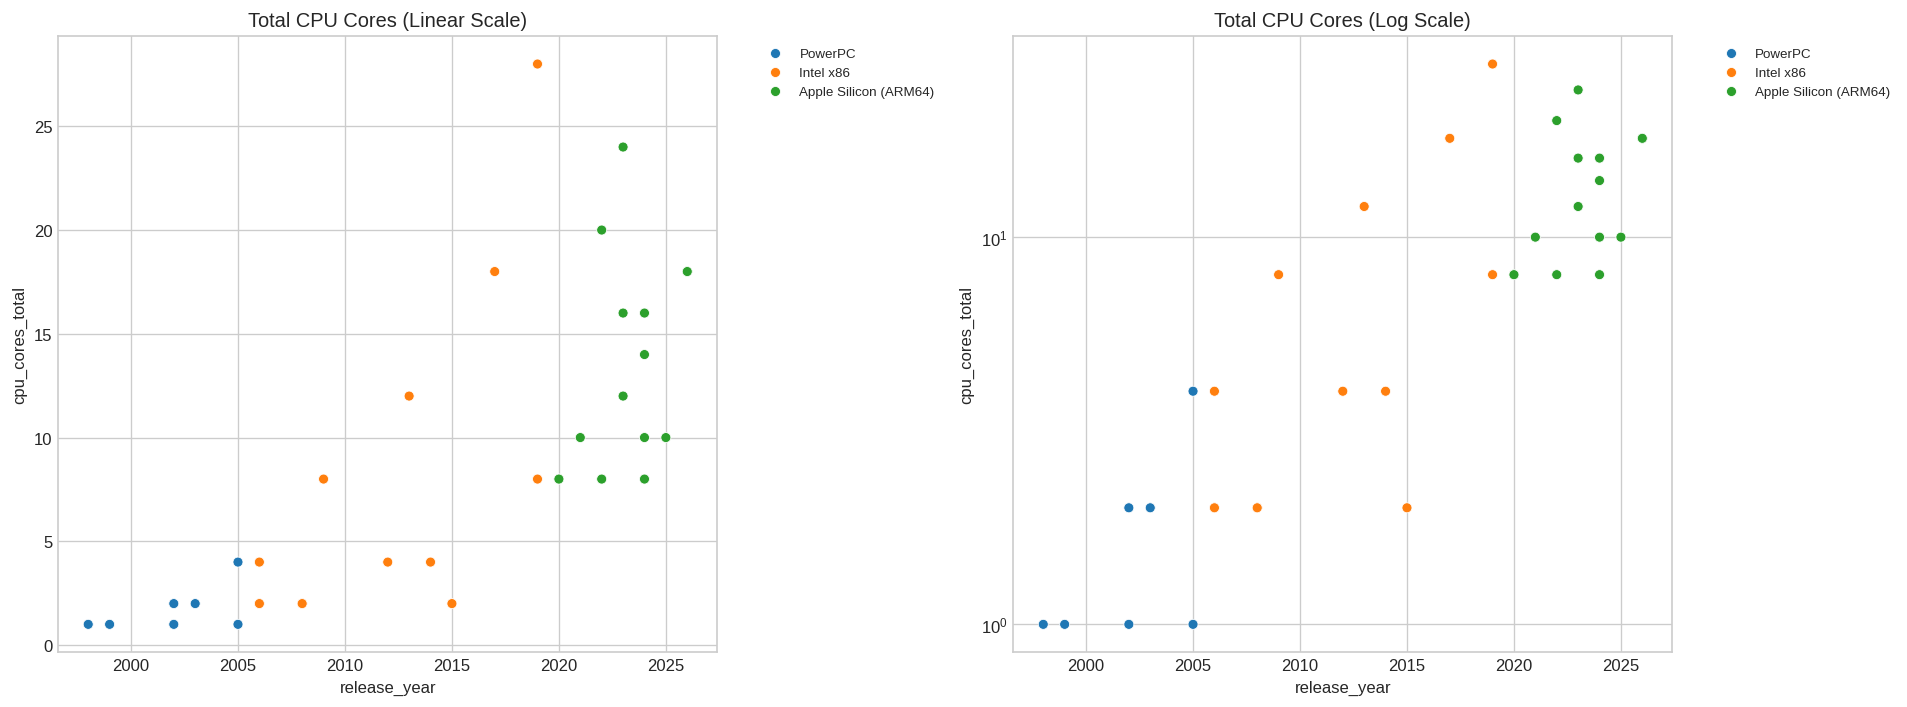

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(data=df, x="release_year", y="cpu_cores_total", hue="cpu_architecture" if "cpu_architecture" in df.columns else None, ax=axes[0])
axes[0].set_title("Total CPU Cores (Linear Scale)")
if axes[0].get_legend(): axes[0].legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
sns.scatterplot(data=df, x="release_year", y="cpu_cores_total", hue="cpu_architecture" if "cpu_architecture" in df.columns else None, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Total CPU Cores (Log Scale)")
if axes[1].get_legend(): axes[1].legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

# **Cell 5**

In [8]:
if "tdp_watts" in df.columns and "geekbench6_multi_core" in df.columns:
    plt.figure(figsize=(10, 5))
    sns.scatterplot(data=df, x="tdp_watts", y="geekbench6_multi_core", hue="release_year", palette="viridis")
    plt.title("Geekbench 6 Multi-Core vs TDP (Watts)")
    plt.yscale("log")
    plt.tight_layout()
    plt.show()
else:
    print("Performance benchmarks (TDP and Geekbench) are not available in this specific dataset file.")
    print(f"Available columns: {list(df.columns)}")

Performance benchmarks (TDP and Geekbench) are not available in this specific dataset file.
Available columns: ['model_name', 'model_family', 'model_id', 'release_year', 'release_date', 'cpu_architecture', 'processor_name', 'cpu_cores_total', 'cpu_p_cores', 'cpu_e_cores']


# **Cell 6**

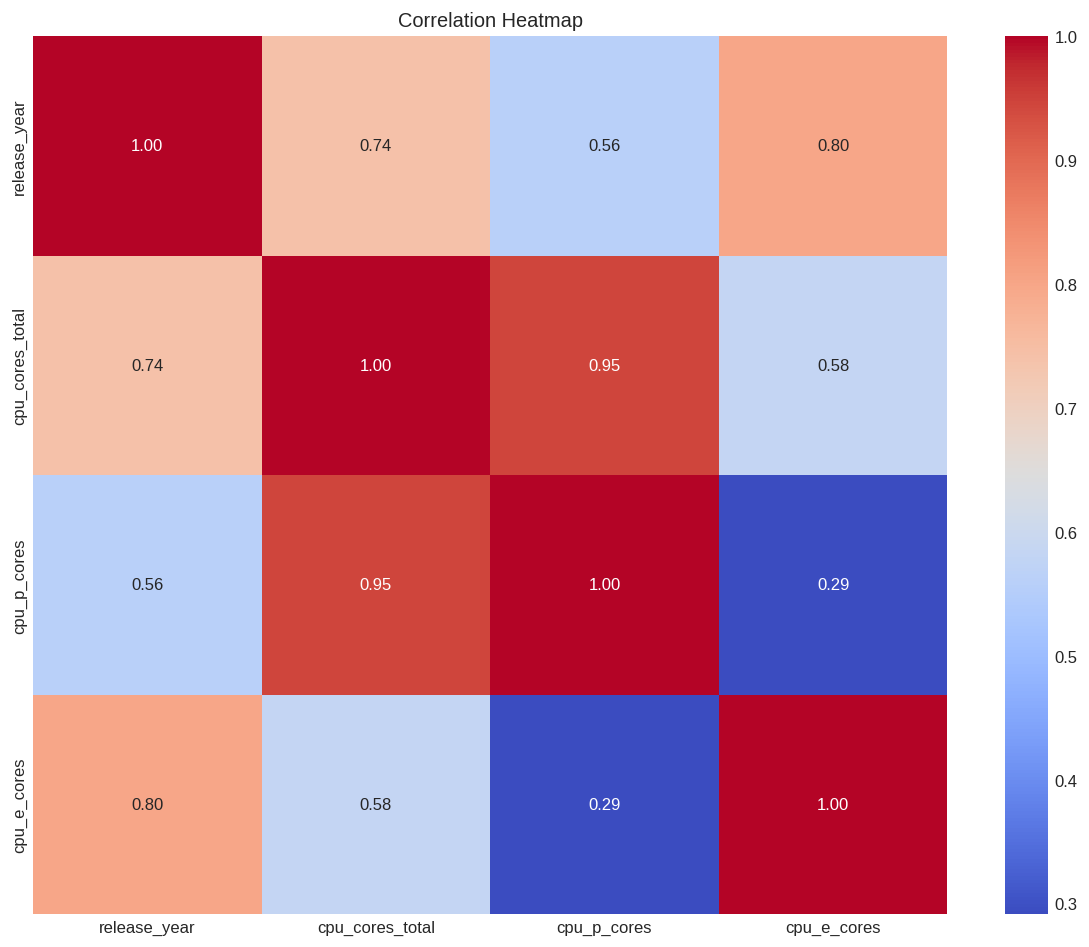

In [9]:
num_cols = df.select_dtypes(include=[np.number]).columns
if len(num_cols) > 2:
    plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# **Cell 7**

In [11]:
name_col = df.columns[0]
print("=== TOP 5 HIGHEST CORE COUNTS ===")
# Using 'cpu_cores_total' as the ranking metric since benchmark scores are missing
display(df.sort_values(by="cpu_cores_total", ascending=False).head(5)[[name_col, "release_year", "cpu_cores_total"]])

=== TOP 5 HIGHEST CORE COUNTS ===


,model_name,release_year,cpu_cores_total
18,Mac Pro 28-Core (2019),2019,28
25,Mac Studio M2 Ultra (2023),2023,24
23,Mac Studio M1 Ultra (2022),2022,20
33,MacBook Pro 14-inch M5 Pro (2026),2026,18
34,MacBook Pro 16-inch M5 Max (2026),2026,18
